In [58]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ahmeduzaki/concrete-compressive-strength-dataset/Concrete Compressive Strength.csv


In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
df=pd.read_csv('/kaggle/input/datasets/ahmeduzaki/concrete-compressive-strength-dataset/Concrete Compressive Strength.csv')[['cement_water_interaction','aggregate_to_cement']]

In [61]:
df.head()

,cement_water_interaction,aggregate_to_cement
0,28754.55,12.174719
1,26736.87,11.113019
2,46850.00,7.272371
3,60648.00,6.022534
4,29922.84,11.266723


<Axes: ylabel='aggregate_to_cement'>

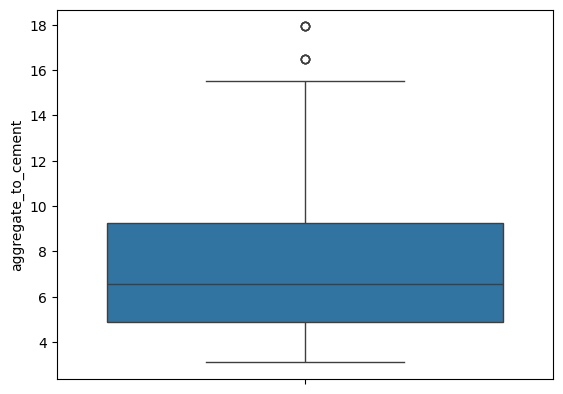

In [63]:
sns.boxplot(df['aggregate_to_cement'])

/tmp/ipykernel_57/3814751521.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['aggregate_to_cement'])


<Axes: xlabel='aggregate_to_cement', ylabel='Density'>

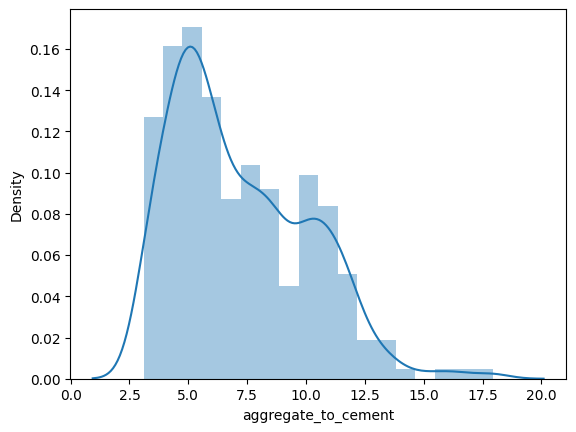

In [64]:
sns.distplot(df['aggregate_to_cement'])

In [65]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [66]:
rs=RobustScaler()

x=df[['aggregate_to_cement']]
y=df['cement_water_interaction']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [67]:
print(x_train.columns)

Index(['aggregate_to_cement'], dtype='object')


In [69]:
x_train[['aggregate_to_cement']].shape

(824, 1)

In [70]:
x_train['aggregate_to_cement_trans']=rs.fit_transform(x_train[['aggregate_to_cement']])

/tmp/ipykernel_57/952140025.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['aggregate_to_cement_trans'])


<Axes: xlabel='aggregate_to_cement_trans', ylabel='Density'>

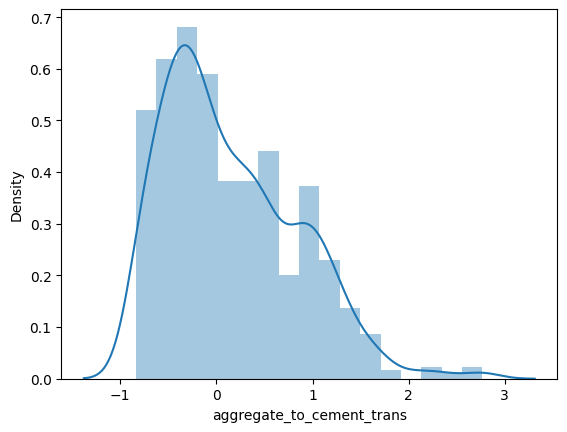

In [73]:
sns.distplot(x_train['aggregate_to_cement_trans'])

## Robust Scaler is not remove the outlier , it only reduce the effect of the outlier